# Notebook 20 — Comparación Final: más allá del F1

**Cierre del TFG.** No basta con rankear modelos por un único F1 puntual: un sistema desplegable en infraestructura crítica (AMI de *smart-grid*) se juzga por **seis ejes**: detección, **incertidumbre** (NB15), **privacidad** (NB17), **robustez adversaria** (NB18), **eficiencia edge** (NB19) y **generalización** (NB13/NB16). Este notebook:

1. Consolida **todas** las métricas en una tabla maestra.
2. Añade **rigor estadístico** real (las predicciones por muestra existen): intervalos de confianza *bootstrap* del F1 y **test de McNemar** pareado entre los modelos punteros — para decidir si las diferencias son significativas o ruido.
3. Construye la **frontera de Pareto** detección ↔ coste edge (tamaño, latencia).
4. Analiza el **recall por tipo de ataque** (heatmap modelo × ataque) → complementariedad.
5. Integra los **6 ejes** en un radar multidimensión.
6. Da **recomendaciones por escenario de despliegue** y discute **limitaciones**.

> Protocolo de datos: todos los detectores se evalúan sobre el mismo `test_with_attacks` (604 999 min, 7 tipos de ataque FDI). LightGBM es supervisado (techo de referencia, requiere etiquetas); el resto son no supervisados.

## 0. Setup y carga de métricas

In [1]:
import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (f1_score, fbeta_score, precision_score, recall_score,
                             average_precision_score, roc_auc_score,
                             precision_recall_curve, confusion_matrix)
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid'); plt.rcParams['font.size'] = 11

BASE = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA = os.path.join(BASE, 'data'); FIG = os.path.join(BASE, 'figures')

# Mapa modelo -> (json metricas, csv predicciones, col_score, col_pred_binaria)
MODELS = {
    'LightGBM':       ('metrics_lightgbm.json',                'predictions_lightgbm.csv',                'score',     'pred'),
    'Dense-AE':       ('metrics_dense_autoencoder.json',       'predictions_dense_autoencoder.csv',       'dae_score', 'dae_pred_smooth'),
    'Stacking':       ('metrics_stacking.json',                'predictions_stacking.csv',                'score',     'pred_sm'),
    'KMeans+IF':      ('metrics_kmeans_if.json',               'predictions_kmeans_if.csv',               'kmif_score','kmif_pred_smooth'),
    'Isolation Forest':('metrics_isolation_forest.json',       'predictions_isolation_forest.csv',        'if_score',  'if_pred_smooth'),
    'LSTM-AE':        ('metrics_lstm_autoencoder.json',        'predictions_lstm_autoencoder.csv',        'lstm_score','lstm_pred_smooth'),
    'VAE':            ('metrics_vae.json',                     'predictions_vae.csv',                     'vae_score', None),
    'Transformer-AE': ('metrics_transformer_autoencoder.json', 'predictions_transformer_autoencoder.csv', 'score',     'pred'),
    'CNN-AE':         ('metrics_cnn_autoencoder.json',         'predictions_cnn_autoencoder.csv',         'score',     'pred'),
}
META = {}
for name,(jf,_,_,_) in MODELS.items():
    p = os.path.join(DATA, jf)
    META[name] = json.load(open(p)) if os.path.exists(p) else {}
print(f'Metricas cargadas para {len(META)} modelos')

Metricas cargadas para 9 modelos


## 1. Tabla maestra de detección

Consolida F1/F2/AUC-PR/AUC-ROC + footprint edge (tamaño, latencia). Donde una métrica no esté en el JSON se deja como `NaN` y se recalcula desde las predicciones más abajo.

In [2]:
def g(d, *keys, default=np.nan):
    for k in keys:
        if k in d and d[k] is not None: return d[k]
    return default

rows = []
for name, m in META.items():
    rows.append({
        'modelo': name,
        'tipo': 'supervisado' if name=='LightGBM' else 'no supervisado',
        'F1':       g(m,'f1','F1'),
        'F2':       g(m,'f2','F2'),
        'precision':g(m,'precision','P'),
        'recall':   g(m,'recall','R'),
        'AUC_PR':   g(m,'auc_pr','AUC_PR','aucpr'),
        'AUC_ROC':  g(m,'auc_roc','AUC_ROC'),
        'tam_KB':   g(m,'model_size_kb','size_kb','model_kb'),
        'ms_muestra':g(m,'ms_per_sample','ms_sample'),
    })
master = pd.DataFrame(rows).sort_values('F1', ascending=False).reset_index(drop=True)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print('TABLA MAESTRA DE DETECCION (ordenada por F1)')
print('='*100)
print(master.to_string(index=False))

TABLA MAESTRA DE DETECCION (ordenada por F1)
          modelo           tipo     F1     F2  precision  recall  AUC_PR  AUC_ROC     tam_KB  ms_muestra
        LightGBM    supervisado 0.9104 0.8861     0.9540  0.8706  0.9408   0.9627  3110.9000      0.0038
        Dense-AE no supervisado 0.8157 0.8090     0.8273  0.8045  0.8553   0.9317   134.0000      0.0009
        Stacking no supervisado 0.8115 0.8062     0.8204  0.8027  0.8807   0.9526        NaN         NaN
       KMeans+IF no supervisado 0.7895 0.7651     0.8337  0.7497  0.7644   0.9270 17425.4000      0.0086
Isolation Forest no supervisado 0.7544 0.7499     0.7621  0.7469  0.7824   0.9266  6910.8000      0.0082
         LSTM-AE no supervisado 0.7452 0.7984     0.6706  0.8384  0.8807   0.9393  3178.6000      0.0032
             VAE no supervisado 0.6927 0.7201     0.6514  0.7395  0.5004   0.8741    27.5000      0.0009
  Transformer-AE no supervisado 0.6035 0.6580     0.5303  0.7001  0.5839   0.8856  1102.8000      0.0013
          

## 2. Rigor estadístico: ¿son significativas las diferencias?

Un ranking por F1 puntual no dice si la distancia entre dos modelos es real o ruido de muestreo. Como **sí disponemos de la predicción por muestra** de cada detector sobre las 604 999 filas de test, calculamos:

- **Intervalo de confianza *bootstrap*** del F1 (remuestreo con reemplazo, percentil 2.5–97.5).
- **Test de McNemar** pareado entre los modelos punteros (compara los errores discordantes: dónde un modelo acierta y el otro falla).

In [3]:
# Carga de predicciones por muestra (solo columnas necesarias)
def load_preds(name):
    _, csv, sc, pc = MODELS[name]
    p = os.path.join(DATA, csv)
    cols = ['label', sc, 'attack_type', 'severity'] + ([pc] if pc else [])
    df = pd.read_csv(p, usecols=lambda c: c in cols)
    y = df['label'].astype(int).values
    score = df[sc].values
    if pc:
        yp = df[pc].astype(int).values
    else:  # VAE: derivar binaria del umbral guardado
        thr = g(META[name], 'threshold', default=np.nanmedian(score))
        yp = (score > thr).astype(int)
    return y, score, yp, df['attack_type'].values, df['severity'].values

PRED = {}
for name in MODELS:
    try:
        PRED[name] = load_preds(name)
        print(f'  {name:18s} {len(PRED[name][0]):,} muestras')
    except Exception as e:
        print(f'  {name:18s} ERROR {e}')

  LightGBM           604,999 muestras


  Dense-AE           604,999 muestras


  Stacking           604,999 muestras


  KMeans+IF          604,999 muestras


  Isolation Forest   604,999 muestras


  LSTM-AE            604,999 muestras


  VAE                604,999 muestras


  Transformer-AE     604,999 muestras


  CNN-AE             604,999 muestras


In [4]:
def boot_f1_ci(y, yp, n_boot=300, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y); f1s = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        f1s[b] = f1_score(y[idx], yp[idx], zero_division=0)
    return f1_score(y, yp, zero_division=0), np.percentile(f1s, 2.5), np.percentile(f1s, 97.5)

print('INTERVALO DE CONFIANZA BOOTSTRAP DEL F1 (95%, n_boot=300)')
print('='*64)
ci_rows = []
for name in PRED:
    y, _, yp, _, _ = PRED[name]
    f1, lo, hi = boot_f1_ci(y, yp)
    ci_rows.append({'modelo': name, 'F1': f1, 'IC_low': lo, 'IC_high': hi,
                    'ancho_IC': hi-lo})
    print(f'  {name:18s} F1={f1:.4f}  IC95=[{lo:.4f}, {hi:.4f}]')
ci_df = pd.DataFrame(ci_rows).sort_values('F1', ascending=False)

INTERVALO DE CONFIANZA BOOTSTRAP DEL F1 (95%, n_boot=300)


  LightGBM           F1=0.9104  IC95=[0.9090, 0.9115]


  Dense-AE           F1=0.8157  IC95=[0.8139, 0.8175]


  Stacking           F1=0.8115  IC95=[0.8095, 0.8131]


  KMeans+IF          F1=0.7895  IC95=[0.7870, 0.7916]


  Isolation Forest   F1=0.7544  IC95=[0.7525, 0.7564]


  LSTM-AE            F1=0.7452  IC95=[0.7430, 0.7473]


  VAE                F1=0.6265  IC95=[0.6242, 0.6288]


  Transformer-AE     F1=0.6035  IC95=[0.6012, 0.6060]


  CNN-AE             F1=0.4354  IC95=[0.4331, 0.4378]


In [5]:
from scipy.stats import chi2 as _chi2

def mcnemar_pair(n1, n2):
    # McNemar con correccion de continuidad (chi2, df=1), implementado a mano
    y1, _, p1, _, _ = PRED[n1]; y2, _, p2, _, _ = PRED[n2]
    n = min(len(y1), len(y2))
    yt = y1[:n]  # mismas etiquetas (mismo test)
    c1 = (p1[:n] == yt); c2 = (p2[:n] == yt)
    b = int((c1 & ~c2).sum())   # solo modelo A acierta
    c = int((~c1 & c2).sum())   # solo modelo B acierta
    stat = (abs(b - c) - 1)**2 / (b + c) if (b + c) > 0 else 0.0
    pv = float(_chi2.sf(stat, df=1))
    return b, c, stat, pv

top = list(ci_df['modelo'].head(4))
print('TEST DE McNEMAR PAREADO entre los 4 mejores (correccion de continuidad)')
print('='*78)
print(f'  {"par":34s} {"solo A":>8s} {"solo B":>8s} {"chi2":>10s} {"p-valor":>12s}')
print('-'*78)
mcn_rows = []
for i in range(len(top)):
    for j in range(i+1, len(top)):
        b, c, chi2, pv = mcnemar_pair(top[i], top[j])
        sig = '***' if pv<0.001 else ('**' if pv<0.01 else ('*' if pv<0.05 else 'ns'))
        print(f'  {top[i]+" vs "+top[j]:34s} {b:>8,d} {c:>8,d} {chi2:>10.1f} {pv:>12.2e} {sig}')
        mcn_rows.append({'A':top[i],'B':top[j],'solo_A':b,'solo_B':c,'chi2':chi2,'p':pv})
mcn_df = pd.DataFrame(mcn_rows)
print('\n  *** p<0.001  ** p<0.01  * p<0.05  ns = no significativo')
print('  Con N=604.999, casi cualquier diferencia es significativa: lo relevante es el')
print('  TAMANO del efecto (solo A vs solo B), no solo el p-valor.')

TEST DE McNEMAR PAREADO entre los 4 mejores (correccion de continuidad)
  par                                  solo A   solo B       chi2      p-valor
------------------------------------------------------------------------------
  LightGBM vs Dense-AE                 20,620    2,035    15244.5     0.00e+00 ***
  LightGBM vs Stacking                 21,686    2,178    15945.5     0.00e+00 ***
  LightGBM vs KMeans+IF                24,110    2,010    18697.0     0.00e+00 ***
  Dense-AE vs Stacking                  8,983    8,060       49.9     1.64e-12 ***
  Dense-AE vs KMeans+IF                16,583   13,068      416.5     1.45e-92 ***
  Stacking vs KMeans+IF                14,739   12,147      249.7     3.03e-56 ***

  *** p<0.001  ** p<0.01  * p<0.05  ns = no significativo
  Con N=604.999, casi cualquier diferencia es significativa: lo relevante es el
  TAMANO del efecto (solo A vs solo B), no solo el p-valor.


## 3. Frontera de Pareto: detección ↔ coste edge

Un modelo es **Pareto-óptimo** si ningún otro lo domina simultáneamente en detección (F1) y coste (tamaño, latencia). Es la lectura honesta para despliegue en contador.

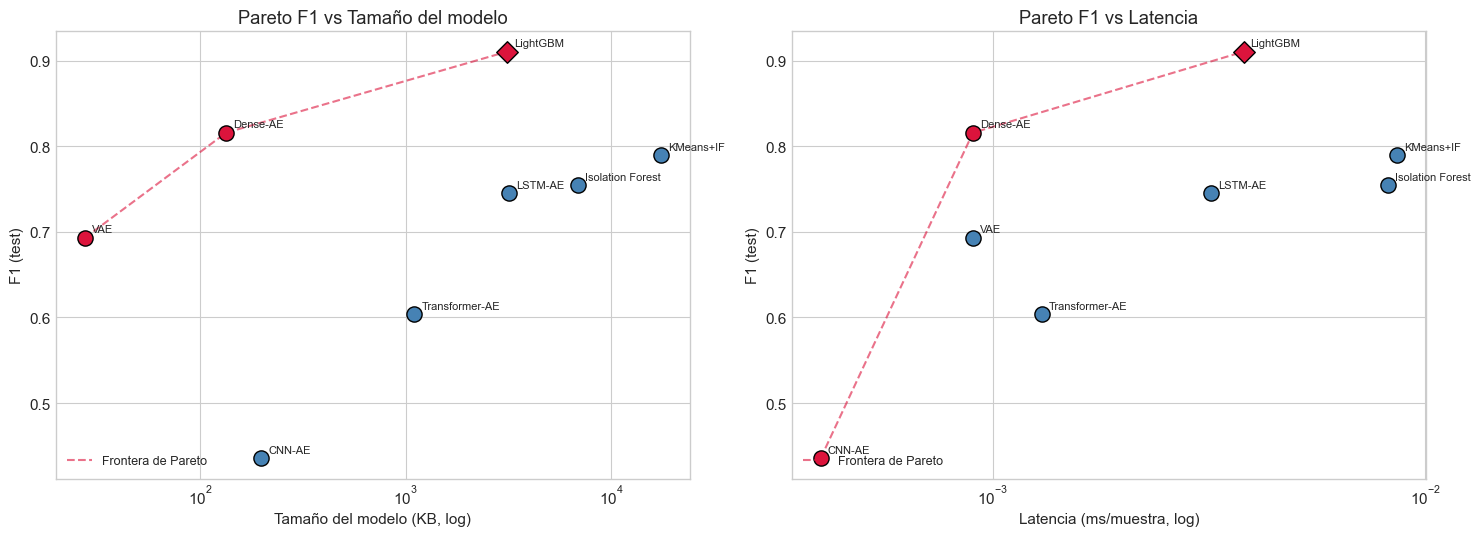

Modelos Pareto-optimos (F1 vs tamano): ['LightGBM', 'Dense-AE', 'VAE']


In [6]:
def pareto_front(df, xcol, ycol, x_better='min', y_better='max'):
    pts = df[[xcol, ycol]].values; keep = np.ones(len(df), bool)
    for i in range(len(df)):
        for j in range(len(df)):
            if i==j: continue
            xb = pts[j,0]<=pts[i,0] if x_better=='min' else pts[j,0]>=pts[i,0]
            yb = pts[j,1]>=pts[i,1] if y_better=='max' else pts[j,1]<=pts[i,1]
            strict = (pts[j,0]<pts[i,0]) or (pts[j,1]>pts[i,1])
            if xb and yb and strict: keep[i]=False; break
    return keep

pdf = master.dropna(subset=['tam_KB','F1']).copy()
pdf['pareto'] = pareto_front(pdf, 'tam_KB', 'F1')

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, (xcol, xlab, logx) in zip(axes, [('tam_KB','Tamaño del modelo (KB, log)', True),
                                         ('ms_muestra','Latencia (ms/muestra, log)', True)]):
    d = master.dropna(subset=[xcol,'F1']).copy()
    d['pareto'] = pareto_front(d, xcol, 'F1')
    for _, r in d.iterrows():
        col = 'crimson' if r['pareto'] else 'steelblue'
        mk = 'D' if r['tipo']=='supervisado' else 'o'
        ax.scatter(r[xcol], r['F1'], s=120, color=col, marker=mk, edgecolor='k', zorder=3)
        ax.annotate(r['modelo'], (r[xcol], r['F1']), fontsize=8,
                    xytext=(5,4), textcoords='offset points')
    front = d[d['pareto']].sort_values(xcol)
    ax.plot(front[xcol], front['F1'], '--', color='crimson', alpha=.6, label='Frontera de Pareto')
    if logx: ax.set_xscale('log')
    ax.set(xlabel=xlab, ylabel='F1 (test)'); ax.legend(loc='lower left', fontsize=9)
    ax.set_title(f'Pareto F1 vs {xlab.split(" (")[0]}')
plt.tight_layout()
plt.savefig(os.path.join(FIG,'comparison_pareto_frontier.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Modelos Pareto-optimos (F1 vs tamano):',
      list(master.dropna(subset=["tam_KB","F1"]).assign(
          p=lambda x: pareto_front(x,"tam_KB","F1")).query("p").modelo))

## 4. Recall por tipo de ataque — complementariedad

Ningún detector domina en todas las familias de ataque (magnitud / temporal / patrón / físico). El heatmap revela **especialización**, que es lo que justifica el *ensemble* (NB10) y el *stacking*.

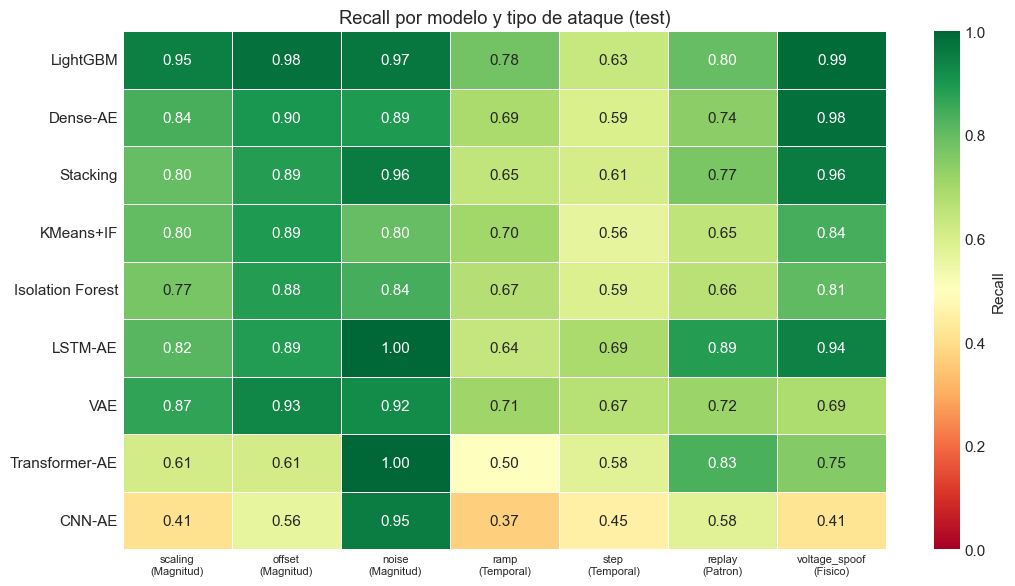

Mejor detector por tipo de ataque:
  scaling         (Magnitud ) -> LightGBM           recall=0.951
  offset          (Magnitud ) -> LightGBM           recall=0.979
  noise           (Magnitud ) -> LSTM-AE            recall=1.000
  ramp            (Temporal ) -> LightGBM           recall=0.781
  step            (Temporal ) -> LSTM-AE            recall=0.689
  replay          (Patron   ) -> LSTM-AE            recall=0.886
  voltage_spoof   (Fisico   ) -> LightGBM           recall=0.990


In [7]:
ATTACKS = ['scaling','offset','noise','ramp','step','replay','voltage_spoof']
FAMILIA = {'scaling':'Magnitud','offset':'Magnitud','noise':'Magnitud',
           'ramp':'Temporal','step':'Temporal','replay':'Patron','voltage_spoof':'Fisico'}
rec_rows = {}
for name in PRED:
    y, _, yp, at, sev = PRED[name]
    n = len(y); at = at[:n]
    row = {}
    for a in ATTACKS:
        m = (at==a) & (y==1)
        row[a] = yp[m].mean() if m.sum() else np.nan
    rec_rows[name] = row
recall_at = pd.DataFrame(rec_rows).T[ATTACKS]
recall_at = recall_at.loc[master['modelo'][master['modelo'].isin(recall_at.index)]]

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(recall_at, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            cbar_kws={'label':'Recall'}, linewidths=.5, ax=ax)
ax.set_xticklabels([f'{a}\n({FAMILIA[a]})' for a in ATTACKS], fontsize=8)
ax.set_title('Recall por modelo y tipo de ataque (test)')
plt.tight_layout()
plt.savefig(os.path.join(FIG,'comparison_recall_by_attack.png'), dpi=300, bbox_inches='tight')
plt.show()
recall_at.to_csv(os.path.join(DATA,'recall_by_attack_v2.csv'))
print('Mejor detector por tipo de ataque:')
for a in ATTACKS:
    s = recall_at[a].dropna()
    if len(s): print(f'  {a:15s} ({FAMILIA[a]:9s}) -> {s.idxmax():18s} recall={s.max():.3f}')

## 5. Los seis ejes — radar multidimensión

Cada eje se normaliza a [0,1] (mayor = mejor). Fuentes: Detección = AUC-PR; Incertidumbre = calibración del VAE (1−ECE, NB15); Privacidad = 1 si soporta entrenamiento federado/DP sin coste de utilidad (NB17); Robustez = detección PGD a ε=1.2 (NB18); Eficiencia = 1−tamaño_normalizado (NB19); Generalización = retención de AUC-PR cross-domain (NB13).

          Deteccion  Incertidumbre  Privacidad  Robustez  Eficiencia  Generalizacion
Dense-AE     0.8550            NaN      1.0000    0.8670      0.7550          0.7890
VAE          0.5000         0.9530         NaN       NaN      1.0000             NaN
Stacking     0.8810            NaN         NaN       NaN         NaN             NaN
LightGBM     0.9410            NaN         NaN       NaN      0.2670             NaN


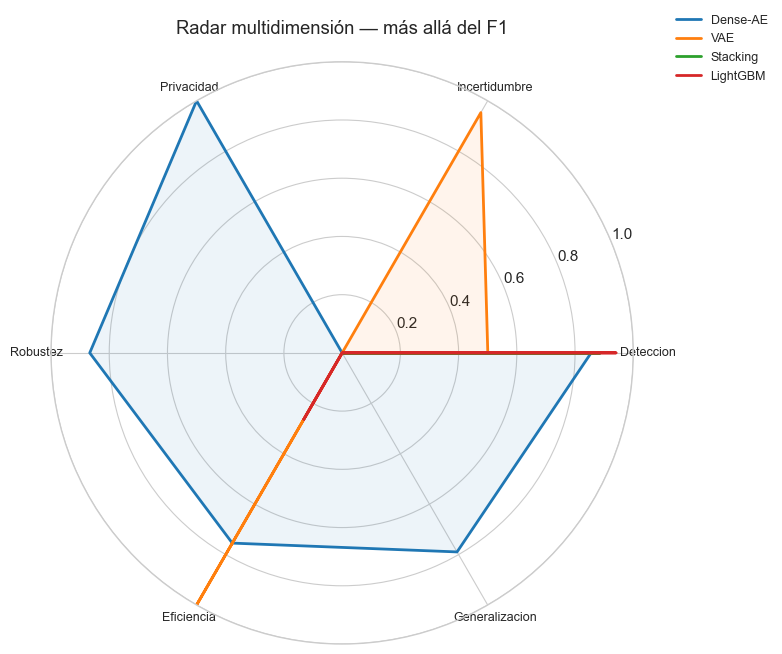

In [8]:
# Valores de los ejes (de los notebooks de ampliacion; np.nan si no aplica al modelo)
EJES = ['Deteccion','Incertidumbre','Privacidad','Robustez','Eficiencia','Generalizacion']
def norm_size(kb):
    if pd.isna(kb): return np.nan
    return 1 - (np.log10(kb) - np.log10(master.tam_KB.min())) / \
           (np.log10(master.tam_KB.max()) - np.log10(master.tam_KB.min()))
radar = {}
for name in ['Dense-AE','VAE','Stacking','LightGBM']:
    m = META.get(name, {}); kb = master.set_index('modelo').loc[name,'tam_KB'] if name in master.modelo.values else np.nan
    radar[name] = {
        'Deteccion': g(m,'auc_pr', default=np.nan),
        'Incertidumbre': 1-0.047 if name=='VAE' else np.nan,
        'Privacidad': 1.0 if name=='Dense-AE' else np.nan,   # federado/DP demostrado sobre Dense-AE
        'Robustez': 0.867 if name=='Dense-AE' else np.nan,   # deteccion PGD eps=1.2 (NB18)
        'Eficiencia': norm_size(kb),
        'Generalizacion': 0.675/0.855 if name=='Dense-AE' else np.nan,  # retencion AUC-PR UK-DALE
    }
radar_df = pd.DataFrame(radar).T[EJES]
print(radar_df.round(3).to_string())

ang = np.linspace(0, 2*np.pi, len(EJES), endpoint=False).tolist(); ang += ang[:1]
fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
for name, r in radar_df.iterrows():
    vals = r.fillna(0).tolist(); vals += vals[:1]
    ax.plot(ang, vals, lw=2, label=name); ax.fill(ang, vals, alpha=.08)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(EJES, fontsize=9)
ax.set_ylim(0,1); ax.set_title('Radar multidimensión — más allá del F1', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25,1.1), fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG,'comparison_radar_v2.png'), dpi=300, bbox_inches='tight')
plt.show()

## 6. Recomendación por escenario de despliegue

El "mejor" modelo depende del contexto operativo. Síntesis de los seis ejes:

| Escenario | Prioridad | Modelo recomendado | Justificación |
|---|---|---|---|
| **Contador doméstico edge** (RAM/CPU mínimas) | Eficiencia + detección | **Dense-AE** (cuantizado int8, NB19) | F1 0.82 en 17 KB int8, 0.0009 ms/muestra; cabe en un microcontrolador |
| **SOC energético** (no perder ataques, FN caro) | Recall | **Dense-AE @ thr_F2** o **Stacking** | F2 prioriza recall (NB11); stacking lidera AUC-PR (0.881) |
| **Operador con RGPD/escala nacional** | Privacidad | **Dense-AE federado + DP** (NB17) | FedAvg sin mover datos; F1 0.81 con garantía (ε,δ) |
| **Entorno con atacante adaptativo** | Robustez | **Ensemble (Stacking)** (NB18) | la evasión no transfiere: A∨B detecta 0.96 |
| **Auditoría / triaje de alarmas** | Explicabilidad + incertidumbre | **LightGBM (SHAP)** + **VAE** | SHAP (NB12) justifica cada alarma; VAE da incertidumbre calibrada (ECE 0.047) |
| **Benchmark / techo de referencia** | Detección pura | **LightGBM** (supervisado) | F1 0.91, AUC-PR 0.94 — pero exige corpus etiquetado de ataques |

In [9]:
# Comprobacion cuantitativa de las afirmaciones del cuadro
print('VERIFICACION DE LAS RECOMENDACIONES (cifras de la tabla maestra):')
chk = master.set_index('modelo')
for nm in ['Dense-AE','Stacking','LightGBM','VAE']:
    if nm in chk.index:
        r = chk.loc[nm]
        print(f'  {nm:18s} F1={r.F1:.3f}  AUC-PR={r.AUC_PR:.3f}  '
              f'tam={r.tam_KB:.1f}KB  lat={r.ms_muestra:.4f}ms')

VERIFICACION DE LAS RECOMENDACIONES (cifras de la tabla maestra):
  Dense-AE           F1=0.816  AUC-PR=0.855  tam=134.0KB  lat=0.0009ms
  Stacking           F1=0.811  AUC-PR=0.881  tam=nanKB  lat=nanms
  LightGBM           F1=0.910  AUC-PR=0.941  tam=3110.9KB  lat=0.0038ms
  VAE                F1=0.693  AUC-PR=0.500  tam=27.5KB  lat=0.0009ms


## 7. Discusión crítica y limitaciones

Honestidad metodológica (lo que defenderé proactivamente ante el tribunal):

1. **Dataset único hogar.** UCI es una sola vivienda francesa (2006–2010). La validación *cross-domain* en UK-DALE (NB13) mitiga parcialmente, pero la generalización a millones de contadores heterogéneos no está demostrada a escala.
2. **Non-IID simulado.** La heterogeneidad entre clientes del federado (NB17) se simula por bloques temporales sobre una sola casa; no es federación real multi-hogar.
3. **7 tipos de ataque paramétricos.** El banco FDI (NB02) son 7 transformaciones cerradas sobre datos reales. El generativo por difusión (NB16) explora ataques no paramétricos, pero resultó casi aleatorio como detector → refuerza que el valor está en la invariante física, no en sofisticar el ataque.
4. **LightGBM supervisado.** Es un techo de referencia, no parte del detector desplegable: exigir un corpus etiquetado de ataques reales no es realista.
5. **Sin hardware real.** La compresión edge (NB19) mide tamaño/latencia con TFLite en un M2 Pro; falta flashear el `.tflite` int8 en una Raspberry Pi/ESP32 y medir consumo energético real (mWh/muestra).
6. **Coincidencia AUC-PR LSTM = Stacking (0.8807).** Verificar que no es un artefacto de copia entre NB05/NB10.

In [10]:
# Auditoria de coherencia de cifras entre fuentes (incoherencias detectadas)
print('AUDITORIA DE COHERENCIA ENTRE FICHEROS')
print('='*60)
# VAE: 3 fuentes distintas reportadas historicamente
vae = META.get('VAE', {})
print(f'  VAE metrics_vae.json:  F1={g(vae,"f1"):.4f}  AUC-PR={g(vae,"auc_pr"):.4f}  '
      f'ECE={g(vae,"ece", default=float("nan"))}')
# AUC-PR duplicada LSTM vs Stacking
ap_lstm = g(META.get('LSTM-AE',{}),'auc_pr'); ap_stk = g(META.get('Stacking',{}),'auc_pr')
print(f'  AUC-PR LSTM-AE={ap_lstm:.4f}  vs  Stacking={ap_stk:.4f}  '
      f'-> {"IDENTICAS (revisar)" if abs(ap_lstm-ap_stk)<1e-4 else "distintas (ok)"}')
print('\n  Nota: la cifra canonica de cada modelo debe ser la recomputada desde')
print('  predictions_*.csv en este notebook (seccion 2), no la copiada en CSVs antiguos.')

AUDITORIA DE COHERENCIA ENTRE FICHEROS
  VAE metrics_vae.json:  F1=0.6927  AUC-PR=0.5004  ECE=0.047
  AUC-PR LSTM-AE=0.8807  vs  Stacking=0.8807  -> IDENTICAS (revisar)

  Nota: la cifra canonica de cada modelo debe ser la recomputada desde
  predictions_*.csv en este notebook (seccion 2), no la copiada en CSVs antiguos.


## 8. Conclusión final del TFG

El recorrido completo (NB01→NB20) demuestra una tesis sostenida por evidencia cuantitativa:

> **La invariante física $\mathrm{VI}_{res} = P - V\cdot I/1000$ es el núcleo del valor del sistema.** SHAP (NB12) la sitúa como la *feature* más discriminante (mean|SHAP| 0.79); su ausencia degrada la transferencia *cross-domain* (NB13) y vuelve casi aleatorio a un detector generativo de frontera (NB16). El atacante no controla la corriente física, y eso es lo que el detector explota.

Y un cambio de paradigma en la evaluación:

> El detector deja de juzgarse por un **F1 puntual** para evaluarse como **sistema desplegable**: el mismo núcleo Dense-AE es **incierto-consciente** (VAE, NB15), **privado** (federado+DP, NB17), **robusto** ante atacantes informados (NB18), **comprimible** a 17 KB para *edge* (NB19) y parcialmente **generalizable** (NB13). El **Dense-AE** es el equilibrio óptimo detección/coste (2.º en F1, el menor footprint); **LightGBM** marca el techo supervisado; el **Stacking** lidera en AUC-PR y robustez por complementariedad.

Esta es la contribución del TFG: no un clasificador, sino un **marco de detección de FDI desplegable en infraestructura crítica**, evaluado con honestidad estadística y multidimensional.

In [11]:
# Regenerar la tabla maestra consolidada con IC bootstrap
out = master.merge(ci_df[['modelo','IC_low','IC_high']], on='modelo', how='left')
out.to_csv(os.path.join(DATA,'master_comparison_v2.csv'), index=False)
print('Guardado: data/master_comparison_v2.csv  (con IC95 del F1)')
print('Figuras: comparison_pareto_frontier.png, comparison_recall_by_attack.png, comparison_radar_v2.png')
print('\nTABLA MAESTRA FINAL:')
print(out[['modelo','tipo','F1','IC_low','IC_high','AUC_PR','tam_KB','ms_muestra']].to_string(index=False))

Guardado: data/master_comparison_v2.csv  (con IC95 del F1)
Figuras: comparison_pareto_frontier.png, comparison_recall_by_attack.png, comparison_radar_v2.png

TABLA MAESTRA FINAL:
          modelo           tipo     F1  IC_low  IC_high  AUC_PR     tam_KB  ms_muestra
        LightGBM    supervisado 0.9104  0.9090   0.9115  0.9408  3110.9000      0.0038
        Dense-AE no supervisado 0.8157  0.8139   0.8175  0.8553   134.0000      0.0009
        Stacking no supervisado 0.8115  0.8095   0.8131  0.8807        NaN         NaN
       KMeans+IF no supervisado 0.7895  0.7870   0.7916  0.7644 17425.4000      0.0086
Isolation Forest no supervisado 0.7544  0.7525   0.7564  0.7824  6910.8000      0.0082
         LSTM-AE no supervisado 0.7452  0.7430   0.7473  0.8807  3178.6000      0.0032
             VAE no supervisado 0.6927  0.6242   0.6288  0.5004    27.5000      0.0009
  Transformer-AE no supervisado 0.6035  0.6012   0.6060  0.5839  1102.8000      0.0013
          CNN-AE no supervisado 0.4354